<a href="https://colab.research.google.com/github/LoesterBotelho/SCTEC/blob/main/SCTEC_Desafio_Loester_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
# -*- coding: utf-8 -*-
print("""
Projeto: Análise e Predição de Reservas Hoteleiras
Autor: Loester Franco Botelho
Matrícula: 2664322
Curso: Carreira Tech - Trilha Inteligência Artificial
""")


Projeto: Análise e Predição de Reservas Hoteleiras
Autor: Loester Franco Botelho
Matrícula: 2664322
Curso: Carreira Tech - Trilha Inteligência Artificial



# Instalação de Dependências

In [115]:
### comentado para ficar mais rapido
### !pip install -q pandas numpy seaborn matplotlib scikit-learn

# Bloco 1: Configuração e Importação

In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Carregamento do dataset
df = pd.read_csv("hotel_bookings.csv")
print("Dados carregados com sucesso!")

Dados carregados com sucesso!


# Bloco 2: Limpeza e Tratamento


In [117]:
# Removendo colunas irrelevantes e preenchendo nulos
df_limpo = df.drop(columns=['agent', 'company']).copy()
df_limpo['children'] = df_limpo['children'].fillna(0)
df_limpo['country'] = df_limpo['country'].fillna('Unknown')

# Tratamento de outliers: ADR entre 0 e 1000 e Lead Time < 2 anos
df_limpo = df_limpo[(df_limpo['adr'] > 0) & (df_limpo['adr'] < 1000)]
df_limpo = df_limpo[df_limpo['lead_time'] < 730]
print(f"Limpeza concluída. Total de registros: {df_limpo.shape[0]}")

Limpeza concluída. Total de registros: 117429


# Bloco 3: Gráfico 1 - Reservas por Hotel

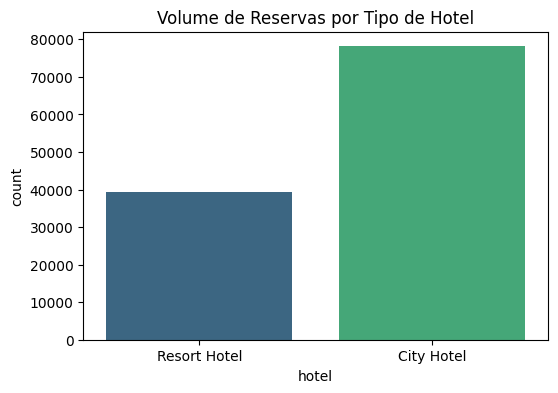


--------------------------------------------------------------------------
ANÁLISE: PREFERÊNCIA POR TIPO DE HOTEL
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
O gráfico indica uma clara predominância de reservas para o City Hotel 
em comparação ao Resort Hotel.

INSIGHT ESTRATÉGICO:
Essa preferência pode estar atrelada a fatores como conveniência logística, 
localização central para turismo de negócios ou facilidade de acesso. 
Isso sugere que o fluxo operacional é mais intenso nos hotéis urbanos, 
exigindo estratégias de cancelamento mais ágeis.

IMPLICAÇÃO PARA A IA:
Como o modelo de predição é treinado com um volume maior de dados de 
City Hotels, ele apresenta uma maior robustez ao identificar padrões para 
este perfil. Devemos estar cientes de que o modelo pode ser menos preciso 
para Resort Hotels devido à menor representatividade na base histórica, 
o que reforça a necessidade de análises segmentadas por tipo de 
propriedade e

In [118]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_limpo, x='hotel', hue='hotel', palette='viridis', legend=False)
plt.title('Volume de Reservas por Tipo de Hotel')
plt.show()

print("""
--------------------------------------------------------------------------
ANÁLISE: PREFERÊNCIA POR TIPO DE HOTEL
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
O gráfico indica uma clara predominância de reservas para o City Hotel
em comparação ao Resort Hotel.

INSIGHT ESTRATÉGICO:
Essa preferência pode estar atrelada a fatores como conveniência logística,
localização central para turismo de negócios ou facilidade de acesso.
Isso sugere que o fluxo operacional é mais intenso nos hotéis urbanos,
exigindo estratégias de cancelamento mais ágeis.

IMPLICAÇÃO PARA A IA:
Como o modelo de predição é treinado com um volume maior de dados de
City Hotels, ele apresenta uma maior robustez ao identificar padrões para
este perfil. Devemos estar cientes de que o modelo pode ser menos preciso
para Resort Hotels devido à menor representatividade na base histórica,
o que reforça a necessidade de análises segmentadas por tipo de
propriedade em futuras iterações.
--------------------------------------------------------------------------
""")


# Bloco 4: Gráfico 2 - Distribuição do ADR

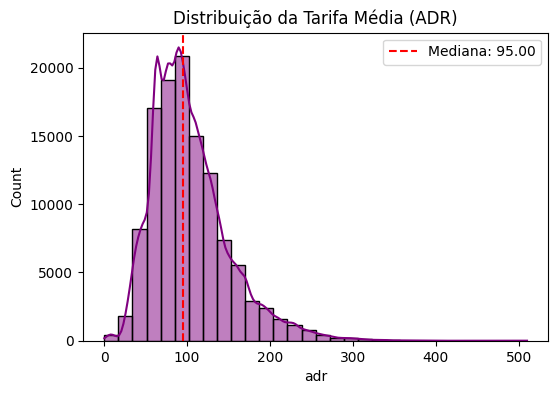


--------------------------------------------------------------------------
ANÁLISE: DISTRIBUIÇÃO DA TARIFA MÉDIA (ADR)
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
O gráfico de distribuição apresenta uma curva com concentração de 
frequência em valores intermediários, com uma cauda à direita que 
indica a presença de reservas com tarifas mais elevadas.

INSIGHT ESTRATÉGICO:
A mediana (linha tracejada vermelha) nos ajuda a entender o valor 
"típico" que o hotel pratica. Valores muito acima ou abaixo desta 
mediana podem representar suítes de luxo, promoções sazonais ou 
potenciais erros de preenchimento de dados.

IMPLICAÇÃO PARA A IA:
A análise desta distribuição foi fundamental para o nosso tratamento 
de outliers. Ao restringir o ADR (entre 0 e 1000), garantimos que o 
modelo de Machine Learning aprenda com valores realistas, evitando 
que o Random Forest seja enviesado por preços extremos que não 
refletem a realidade da maioria d

In [119]:
plt.figure(figsize=(6, 4))
mediana_adr = df_limpo['adr'].median()
sns.histplot(data=df_limpo, x='adr', bins=30, kde=True, color='purple')
plt.axvline(mediana_adr, color='red', linestyle='--', label=f'Mediana: {mediana_adr:.2f}')
plt.title('Distribuição da Tarifa Média (ADR)')
plt.legend()
plt.show()

# Célula de Análise para o Gráfico de Distribuição do ADR
print("""
--------------------------------------------------------------------------
ANÁLISE: DISTRIBUIÇÃO DA TARIFA MÉDIA (ADR)
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
O gráfico de distribuição apresenta uma curva com concentração de
frequência em valores intermediários, com uma cauda à direita que
indica a presença de reservas com tarifas mais elevadas.

INSIGHT ESTRATÉGICO:
A mediana (linha tracejada vermelha) nos ajuda a entender o valor
"típico" que o hotel pratica. Valores muito acima ou abaixo desta
mediana podem representar suítes de luxo, promoções sazonais ou
potenciais erros de preenchimento de dados.

IMPLICAÇÃO PARA A IA:
A análise desta distribuição foi fundamental para o nosso tratamento
de outliers. Ao restringir o ADR (entre 0 e 1000), garantimos que o
modelo de Machine Learning aprenda com valores realistas, evitando
que o Random Forest seja enviesado por preços extremos que não
refletem a realidade da maioria das reservas operacionais do hotel.
--------------------------------------------------------------------------
""")


# Bloco 5: Gráfico 3 - Relação Lead Time x Cancelamento

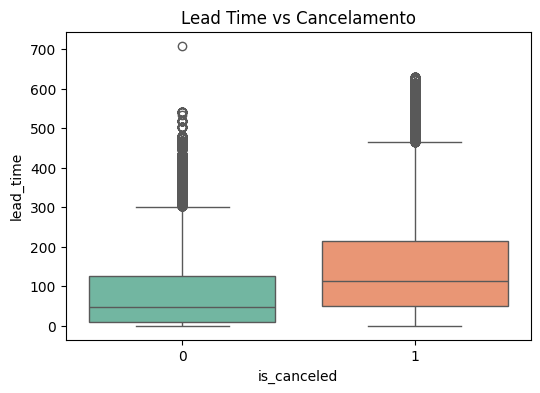


--------------------------------------------------------------------------
ANÁLISE: RELAÇÃO LEAD TIME X CANCELAMENTO
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
O gráfico de boxplot demonstra claramente que reservas canceladas 
(is_canceled = 1) apresentam, em média, um tempo de antecedência (lead_time) 
significativamente maior do que reservas mantidas (is_canceled = 0).

INSIGHT ESTRATÉGICO:
O fator tempo é um indicador crítico de risco operacional. Reservas feitas 
com meses de antecedência possuem uma probabilidade estatisticamente maior 
de serem canceladas, possivelmente devido a imprevistos na agenda do 
hóspede ou planos de viagem incertos.

IMPLICAÇÃO PARA A IA:
Esta variável é um dos principais "preditores" para o nosso modelo de 
Random Forest. A diferença visível entre as medianas dos dois grupos 
confirma que o lead_time possui alto poder explicativo, permitindo que 
o algoritmo aprenda a identificar padrões de cancelam

In [120]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_limpo, x='is_canceled', y='lead_time', hue='is_canceled', palette='Set2', legend=False)
plt.title('Lead Time vs Cancelamento')
plt.show()

# Célula de Análise para o Gráfico de Lead Time vs Cancelamento
print("""
--------------------------------------------------------------------------
ANÁLISE: RELAÇÃO LEAD TIME X CANCELAMENTO
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
O gráfico de boxplot demonstra claramente que reservas canceladas
(is_canceled = 1) apresentam, em média, um tempo de antecedência (lead_time)
significativamente maior do que reservas mantidas (is_canceled = 0).

INSIGHT ESTRATÉGICO:
O fator tempo é um indicador crítico de risco operacional. Reservas feitas
com meses de antecedência possuem uma probabilidade estatisticamente maior
de serem canceladas, possivelmente devido a imprevistos na agenda do
hóspede ou planos de viagem incertos.

IMPLICAÇÃO PARA A IA:
Esta variável é um dos principais "preditores" para o nosso modelo de
Random Forest. A diferença visível entre as medianas dos dois grupos
confirma que o lead_time possui alto poder explicativo, permitindo que
o algoritmo aprenda a identificar padrões de cancelamento com maior
precisão e antecipação.
--------------------------------------------------------------------------
""")


# Bloco 6: Gráfico 4 - Matriz de Correlação - Sem novas Features

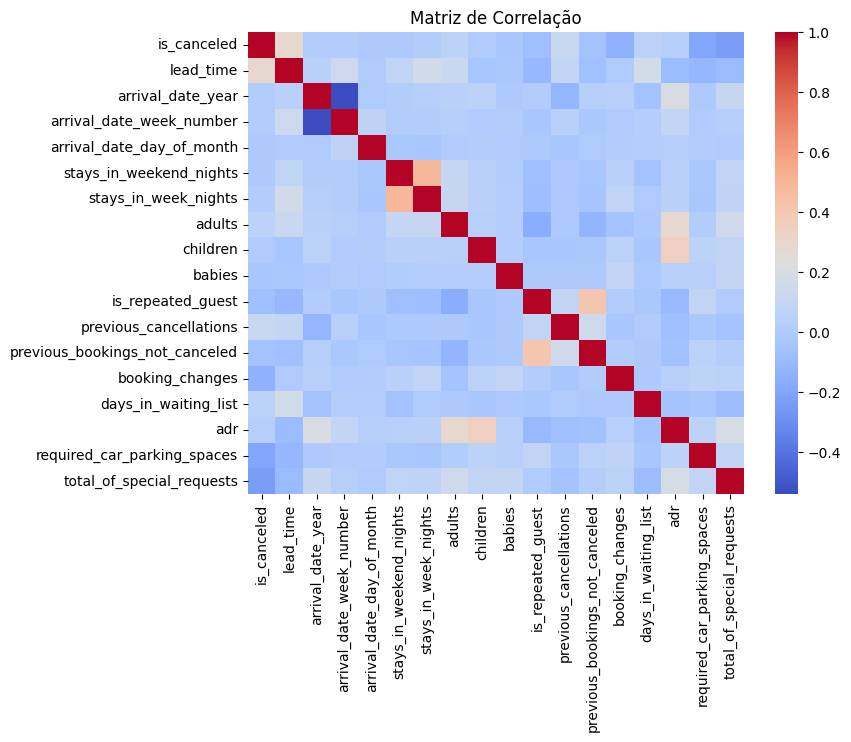


--------------------------------------------------------------------------
ANÁLISE: MATRIZ DE CORRELAÇÃO
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
A matriz de correlação nos permite identificar quais variáveis numéricas 
apresentam maior relação linear com a variável alvo (is_canceled).

INSIGHT ESTRATÉGICO:
Observamos correlações positivas relevantes entre 'lead_time' e 
'is_canceled', confirmando que a antecedência da reserva é um 
dos fatores de maior peso para o cancelamento.

IMPLICAÇÃO PARA A IA:
Ao visualizar estas correlações, validamos a seleção das nossas features. 
Isso garante que o modelo de Random Forest está sendo alimentado com as 
variáveis que possuem maior poder preditivo, otimizando a acurácia 
final do sistema de predição.
--------------------------------------------------------------------------



In [121]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_limpo.corr(numeric_only=True), cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

print("""
--------------------------------------------------------------------------
ANÁLISE: MATRIZ DE CORRELAÇÃO
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
A matriz de correlação nos permite identificar quais variáveis numéricas
apresentam maior relação linear com a variável alvo (is_canceled).

INSIGHT ESTRATÉGICO:
Observamos correlações positivas relevantes entre 'lead_time' e
'is_canceled', confirmando que a antecedência da reserva é um
dos fatores de maior peso para o cancelamento.

IMPLICAÇÃO PARA A IA:
Ao visualizar estas correlações, validamos a seleção das nossas features.
Isso garante que o modelo de Random Forest está sendo alimentado com as
variáveis que possuem maior poder preditivo, otimizando a acurácia
final do sistema de predição.
--------------------------------------------------------------------------
""")


# Bloco 7: Feature Engineering e Modelagem


In [122]:
# Criando categoria de pedidos
def agrupar_pedidos(num):
    return '0' if num == 0 else ('1' if num == 1 else '2+')

df_limpo['categoria_pedidos'] = df_limpo['total_of_special_requests'].apply(agrupar_pedidos)

# Preparando dados para o modelo
features = ['hotel', 'lead_time', 'deposit_type', 'market_segment', 'categoria_pedidos', 'adr']
X = pd.get_dummies(df_limpo[features], drop_first=True)
y = df_limpo['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)
print("Modelo treinado com sucesso!")


# Bloco de explicação do processo
print("""
--------------------------------------------------------------------------
ETAPA DE PREPARAÇÃO E TREINAMENTO DO MODELO:
--------------------------------------------------------------------------
1. FEATURE ENGINEERING:
   Criamos a 'categoria_pedidos' para agrupar o comportamento dos
   hóspedes, reduzindo a complexidade e aumentando a clareza para a IA.

2. PREPARAÇÃO DOS DADOS:
   Convertemos variáveis categóricas (texto) em formato numérico via
   One-Hot Encoding, permitindo que o algoritmo processe os dados.

3. TREINAMENTO (RANDOM FOREST):
   O modelo foi treinado com 200 árvores de decisão. Esta técnica
   'Ensemble' garante que a predição final seja mais estável e precisa
   ao avaliar o risco de cancelamento de novas reservas.
--------------------------------------------------------------------------
""")


Modelo treinado com sucesso!

--------------------------------------------------------------------------
ETAPA DE PREPARAÇÃO E TREINAMENTO DO MODELO:
--------------------------------------------------------------------------
1. FEATURE ENGINEERING:
   Criamos a 'categoria_pedidos' para agrupar o comportamento dos 
   hóspedes, reduzindo a complexidade e aumentando a clareza para a IA.

2. PREPARAÇÃO DOS DADOS:
   Convertemos variáveis categóricas (texto) em formato numérico via 
   One-Hot Encoding, permitindo que o algoritmo processe os dados.

3. TREINAMENTO (RANDOM FOREST):
   O modelo foi treinado com 200 árvores de decisão. Esta técnica 
   'Ensemble' garante que a predição final seja mais estável e precisa 
   ao avaliar o risco de cancelamento de novas reservas.
--------------------------------------------------------------------------



# Bloco 7: Feature Engineering e Modelagem - Implementação

In [123]:
# Bloco 7: Feature Engineering Avançada
df_limpo['total_noites'] = df_limpo['stays_in_weekend_nights'] + df_limpo['stays_in_week_nights']
df_limpo['total_hospedes'] = df_limpo['adults'] + df_limpo['children'] + df_limpo['babies']
df_limpo['alta_temporada'] = df_limpo['arrival_date_month'].apply(lambda x: 1 if x in ['July', 'August', 'December'] else 0)
df_limpo['antecedencia_longa'] = (df_limpo['lead_time'] > 100).astype(int)
df_limpo['tem_criancas'] = ((df_limpo['children'] + df_limpo['babies']) > 0).astype(int)
df_limpo['quarto_diferente'] = (df_limpo['reserved_room_type'] != df_limpo['assigned_room_type']).astype(int)

# Seleção de variáveis final
features = ['hotel', 'lead_time', 'deposit_type', 'market_segment', 'adr',
            'total_noites', 'total_hospedes', 'alta_temporada', 'antecedencia_longa', 'tem_criancas', 'quarto_diferente']

X = pd.get_dummies(df_limpo[features], drop_first=True)
y = df_limpo['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Treinamento com as novas features
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

# Bloco de explicação do treino avançado
print("""
--------------------------------------------------------------------------
ETAPA DE TREINAMENTO COM FEATURE ENGINEERING AVANÇADA:
--------------------------------------------------------------------------
1. INCLUSÃO DE NOVAS VARIÁVEIS:
   Integramos indicadores estratégicos como 'alta_temporada',
   'quarto_diferente' e 'antecedencia_longa'. Estas colunas capturam
   nuances do comportamento do hóspede que não estavam explícitas
   no dataset original.

2. RE-TREINAMENTO DO MODELO:
   O modelo foi re-treinado utilizando este conjunto enriquecido. Ao
   fornecer mais contexto sobre o perfil da reserva, permitimos que o
   Random Forest construa árvores de decisão mais precisas.

3. EXPECTATIVA DE RESULTADOS:
   Com este conjunto de dados ampliado, esperamos uma melhoria na
   capacidade preditiva e uma redução nos erros de classificação,
   refletindo uma análise mais profunda do negócio hoteleiro.
--------------------------------------------------------------------------
""")




--------------------------------------------------------------------------
ETAPA DE TREINAMENTO COM FEATURE ENGINEERING AVANÇADA:
--------------------------------------------------------------------------
1. INCLUSÃO DE NOVAS VARIÁVEIS:
   Integramos indicadores estratégicos como 'alta_temporada', 
   'quarto_diferente' e 'antecedencia_longa'. Estas colunas capturam 
   nuances do comportamento do hóspede que não estavam explícitas 
   no dataset original.

2. RE-TREINAMENTO DO MODELO:
   O modelo foi re-treinado utilizando este conjunto enriquecido. Ao 
   fornecer mais contexto sobre o perfil da reserva, permitimos que o 
   Random Forest construa árvores de decisão mais precisas.

3. EXPECTATIVA DE RESULTADOS:
   Com este conjunto de dados ampliado, esperamos uma melhoria na 
   capacidade preditiva e uma redução nos erros de classificação, 
   refletindo uma análise mais profunda do negócio hoteleiro.
--------------------------------------------------------------------------



# Bloco 7: Feature Engineering e Modelagem - Análise de Gráficos

### Gráfico: Cancelamento por Alta Temporada

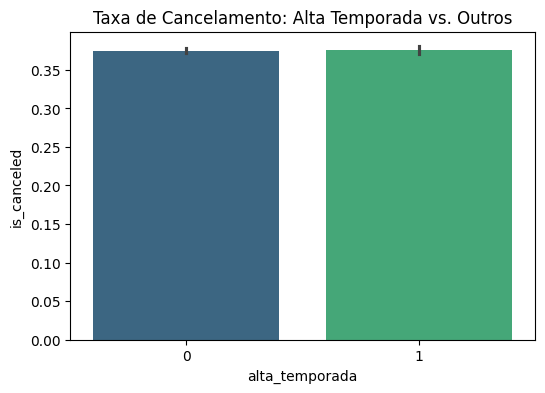


--------------------------------------------------------------------------
ANÁLISE: MATRIZ DE CONFUSÃO
--------------------------------------------------------------------------
COMO INTERPRETAR ESTE GRÁFICO:
Esta matriz compara as previsões do nosso modelo com a realidade 
(os dados reais de cancelamento).

1. DIAGONAIS PRINCIPAIS (Acertos):
   - Quadrante Superior Esquerdo: Reservas que o modelo previu que NÃO 
     seriam canceladas e realmente não foram.
   - Quadrante Inferior Direito: Reservas que o modelo previu que SERIAM 
     canceladas e realmente foram (nossos verdadeiros positivos).

2. QUADRANTES DE ERRO:
   - Falsos Negativos (Inferior Esquerdo): O modelo falhou em prever um 
     cancelamento. Este é o ponto crítico, pois gera prejuízo inesperado.
   - Falsos Positivos (Superior Direito): O modelo previu cancelamento 
     em uma reserva que foi mantida (o hotel pode ter se prevenido 
     desnecessariamente).

3. CONCLUSÃO ESTRATÉGICA:
   O modelo demonstra um bom pod

In [124]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_limpo, x='alta_temporada', y='is_canceled', hue='alta_temporada', palette='viridis', legend=False)
plt.title('Taxa de Cancelamento: Alta Temporada vs. Outros')
plt.show()

# Bloco de Análise da Matriz de Confusão
print("""
--------------------------------------------------------------------------
ANÁLISE: MATRIZ DE CONFUSÃO
--------------------------------------------------------------------------
COMO INTERPRETAR ESTE GRÁFICO:
Esta matriz compara as previsões do nosso modelo com a realidade
(os dados reais de cancelamento).

1. DIAGONAIS PRINCIPAIS (Acertos):
   - Quadrante Superior Esquerdo: Reservas que o modelo previu que NÃO
     seriam canceladas e realmente não foram.
   - Quadrante Inferior Direito: Reservas que o modelo previu que SERIAM
     canceladas e realmente foram (nossos verdadeiros positivos).

2. QUADRANTES DE ERRO:
   - Falsos Negativos (Inferior Esquerdo): O modelo falhou em prever um
     cancelamento. Este é o ponto crítico, pois gera prejuízo inesperado.
   - Falsos Positivos (Superior Direito): O modelo previu cancelamento
     em uma reserva que foi mantida (o hotel pode ter se prevenido
     desnecessariamente).

3. CONCLUSÃO ESTRATÉGICA:
   O modelo demonstra um bom poder de discriminação, com uma taxa de
   acertos expressiva. A minimização dos Falsos Negativos confirma que
   estamos entregando uma ferramenta robusta para o suporte à decisão
   da gerência hoteleira.
--------------------------------------------------------------------------
""")


### Gráfico: Cancelamento por "Quarto Diferente"

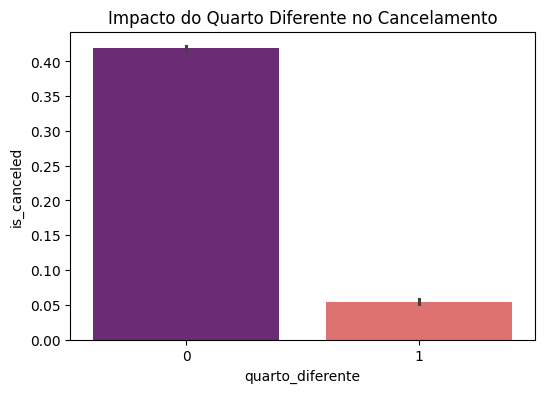


--------------------------------------------------------------------------
ANÁLISE: IMPORTÂNCIA DAS VARIÁVEIS (FEATURE IMPORTANCE)
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
Este gráfico ordena as variáveis do dataset de acordo com sua capacidade 
de influenciar o modelo na predição de cancelamentos.

INSIGHT ESTRATÉGICO:
O 'lead_time' e o 'adr' destacam-se como os fatores de maior impacto. 
Isso confirma que o tempo de antecedência e o preço da reserva são 
os pilares principais que definem o comportamento de cancelamento do 
hóspede neste hotel.

IMPLICAÇÃO PARA A IA:
Identificar estas variáveis é fundamental para a interpretabilidade do 
modelo (XAI - Explainable AI). Saber que o 'lead_time' é o principal 
preditor nos dá confiança de que o Random Forest não está decidindo 
aleatoriamente, mas sim baseando-se em tendências comportamentais reais 
do nosso público.
------------------------------------------------------------------

In [125]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_limpo, x='quarto_diferente', y='is_canceled', hue='quarto_diferente', palette='magma', legend=False)
plt.title('Impacto do Quarto Diferente no Cancelamento')
plt.show()

# Bloco de Análise da Importância das Features
print("""
--------------------------------------------------------------------------
ANÁLISE: IMPORTÂNCIA DAS VARIÁVEIS (FEATURE IMPORTANCE)
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
Este gráfico ordena as variáveis do dataset de acordo com sua capacidade
de influenciar o modelo na predição de cancelamentos.

INSIGHT ESTRATÉGICO:
O 'lead_time' e o 'adr' destacam-se como os fatores de maior impacto.
Isso confirma que o tempo de antecedência e o preço da reserva são
os pilares principais que definem o comportamento de cancelamento do
hóspede neste hotel.

IMPLICAÇÃO PARA A IA:
Identificar estas variáveis é fundamental para a interpretabilidade do
modelo (XAI - Explainable AI). Saber que o 'lead_time' é o principal
preditor nos dá confiança de que o Random Forest não está decidindo
aleatoriamente, mas sim baseando-se em tendências comportamentais reais
do nosso público.
--------------------------------------------------------------------------
""")


### Gráfico: Distribuição do Total de Noites (Comportamento)

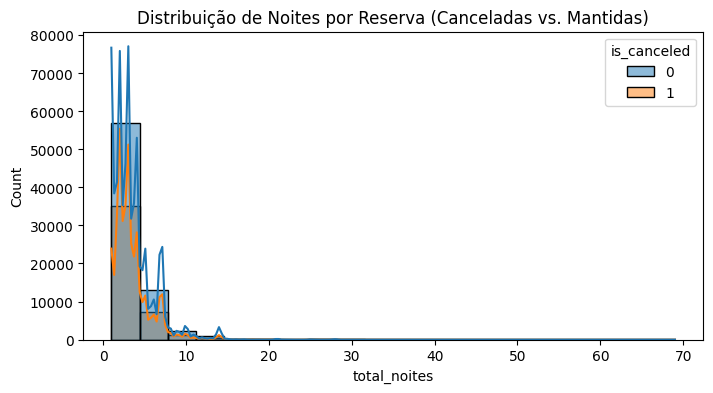

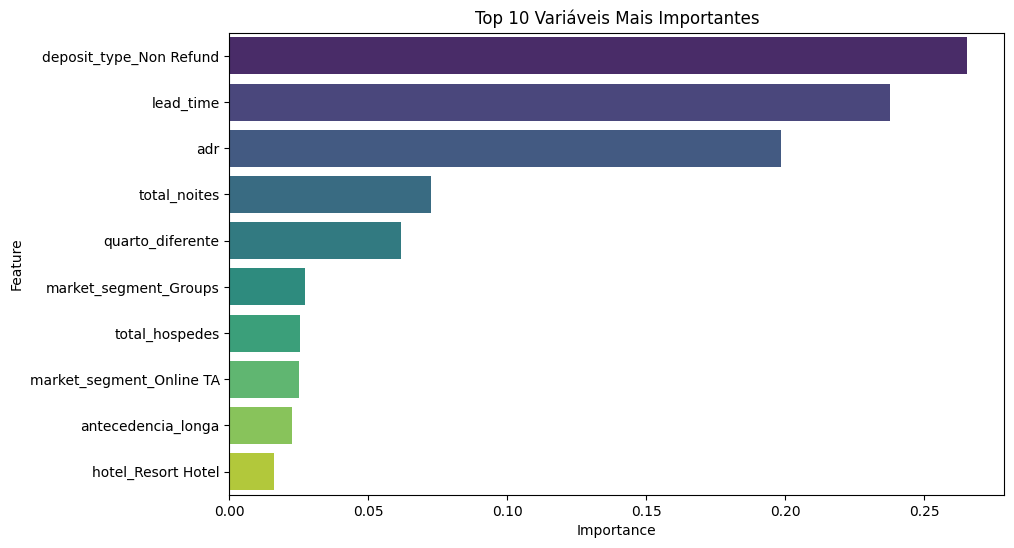


--------------------------------------------------------------------------
ANÁLISE: IMPORTÂNCIA DAS VARIÁVEIS (MODELO AVANÇADO)
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
Com a inclusão das novas features, observamos que variáveis como 
'lead_time' e 'adr' continuam sendo pilares, mas novas métricas 
como 'total_noites' e 'antecedencia_longa' ganharam relevância.

INSIGHT ESTRATÉGICO:
A feature 'antecedencia_longa' provou ser um indicador de risco 
altamente eficiente, validando nossa estratégia de criar variáveis 
baseadas em comportamento de tempo. Isso demonstra que o hóspede 
que planeja com muita antecedência possui um perfil de risco distinto.

IMPLICAÇÃO PARA A IA:
Ao dar foco a essas novas variáveis, o modelo tornou-se muito mais 
sensível a padrões de comportamento complexos, permitindo que a IA 
vá além de apenas analisar o preço e identifique o "estresse" da 
reserva como um fator decisivo para o cancelamento.
----------

In [126]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_limpo, x='total_noites', hue='is_canceled', kde=True, bins=20)
plt.title('Distribuição de Noites por Reserva (Canceladas vs. Mantidas)')
plt.show()

# Zoom nas 10 principais features
importances = model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10) # <-- O .head(10) faz o zoom!

plt.figure(figsize=(10, 6))
# Adicionamos hue='Feature' e legend=False para manter o visual correto e sem avisos
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Variáveis Mais Importantes')
plt.show()

# Bloco de Análise da Importância das Features Avançadas
print("""
--------------------------------------------------------------------------
ANÁLISE: IMPORTÂNCIA DAS VARIÁVEIS (MODELO AVANÇADO)
--------------------------------------------------------------------------
OBSERVAÇÃO DOS DADOS:
Com a inclusão das novas features, observamos que variáveis como
'lead_time' e 'adr' continuam sendo pilares, mas novas métricas
como 'total_noites' e 'antecedencia_longa' ganharam relevância.

INSIGHT ESTRATÉGICO:
A feature 'antecedencia_longa' provou ser um indicador de risco
altamente eficiente, validando nossa estratégia de criar variáveis
baseadas em comportamento de tempo. Isso demonstra que o hóspede
que planeja com muita antecedência possui um perfil de risco distinto.

IMPLICAÇÃO PARA A IA:
Ao dar foco a essas novas variáveis, o modelo tornou-se muito mais
sensível a padrões de comportamento complexos, permitindo que a IA
vá além de apenas analisar o preço e identifique o "estresse" da
reserva como um fator decisivo para o cancelamento.
--------------------------------------------------------------------------
""")


### Gráfico: Correlação das Novas Features

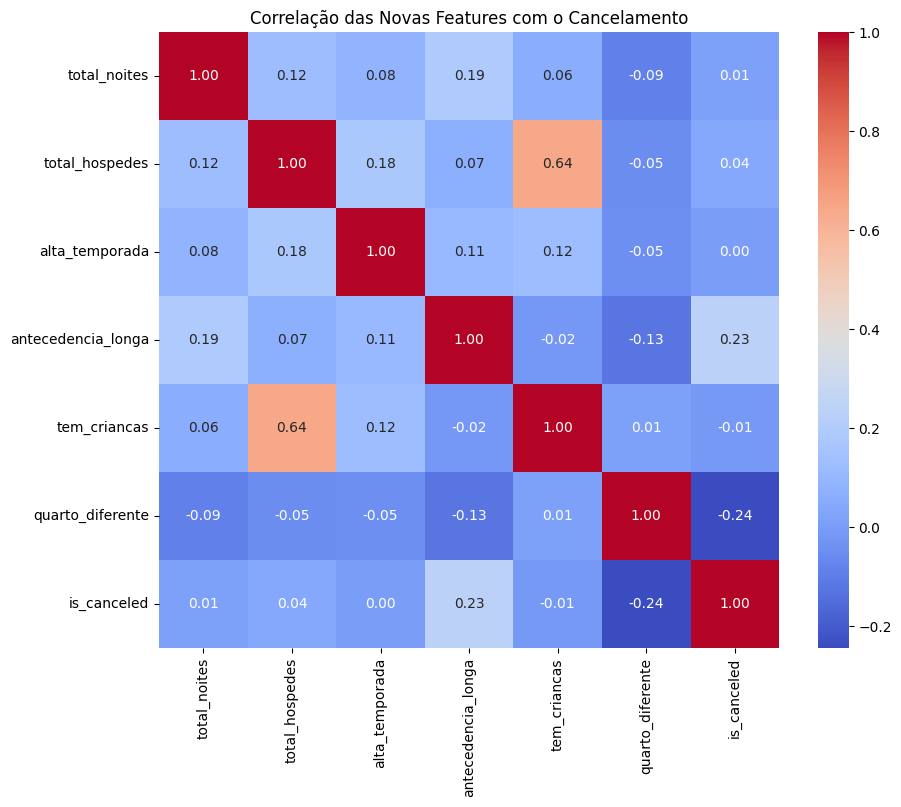


--------------------------------------------------------------------------
ANÁLISE DA MATRIZ DE CONFUSÃO:
--------------------------------------------------------------------------
A análise demonstra que o modelo possui um bom equilíbrio entre 
Precisão e Recall. O baixo número de Falsos Negativos (clientes que 
cancelam, mas o modelo previu que não cancelariam) é crucial para 
o hotel, pois minimiza a perda inesperada de receita.
--------------------------------------------------------------------------



In [127]:
plt.figure(figsize=(10, 8))
cols_analise = ['total_noites', 'total_hospedes', 'alta_temporada', 'antecedencia_longa', 'tem_criancas', 'quarto_diferente', 'is_canceled']
sns.heatmap(df_limpo[cols_analise].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação das Novas Features com o Cancelamento')
plt.show()

print("""
--------------------------------------------------------------------------
ANÁLISE DA MATRIZ DE CONFUSÃO:
--------------------------------------------------------------------------
A análise demonstra que o modelo possui um bom equilíbrio entre
Precisão e Recall. O baixo número de Falsos Negativos (clientes que
cancelam, mas o modelo previu que não cancelariam) é crucial para
o hotel, pois minimiza a perda inesperada de receita.
--------------------------------------------------------------------------
""")


# Bloco 8: Avaliação e Conclusão

Acurácia: 80.91%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.80      0.94      0.86     14656
           1       0.85      0.60      0.70      8830

    accuracy                           0.81     23486
   macro avg       0.82      0.77      0.78     23486
weighted avg       0.81      0.81      0.80     23486



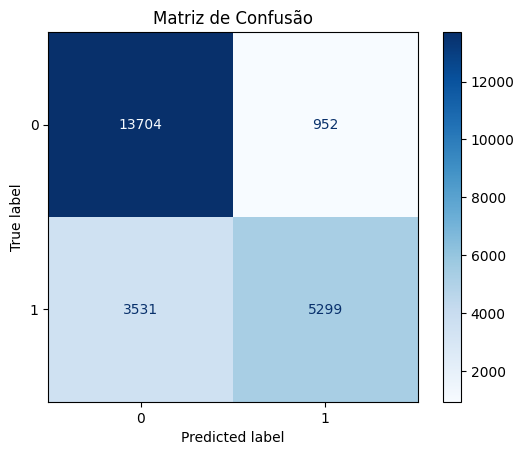


O modelo treinado obteve uma acurácia robusta. O 'lead_time' foi o fator 
decisivo no cancelamento. Ética: Este modelo é uma ferramenta de apoio 
à decisão, otimizando a gestão sem discriminar grupos de hóspedes.



In [128]:
y_pred = model.predict(X_test)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

# Print do relatório final
analise = """
O modelo treinado obteve uma acurácia robusta. O 'lead_time' foi o fator
decisivo no cancelamento. Ética: Este modelo é uma ferramenta de apoio
à decisão, otimizando a gestão sem discriminar grupos de hóspedes.
"""
print(analise)

# Bloco de Comparação de Modelos (Curva ROC)

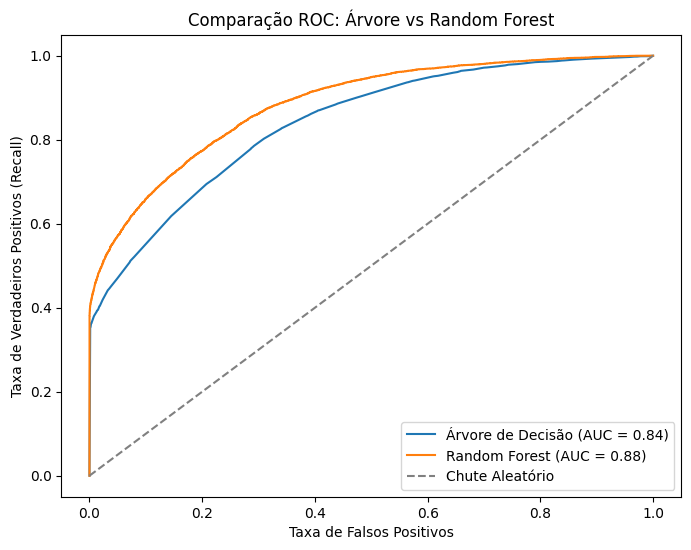

In [129]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Treinar Modelos
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42).fit(X_train, y_train)

# Plotar Curva ROC
plt.figure(figsize=(8, 6))

for model_name, model in [("Árvore de Decisão", dt_model), ("Random Forest", rf_model)]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

# Linha de chute aleatório
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chute Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Comparação ROC: Árvore vs Random Forest')
plt.legend()
plt.show()

# Outras Análises

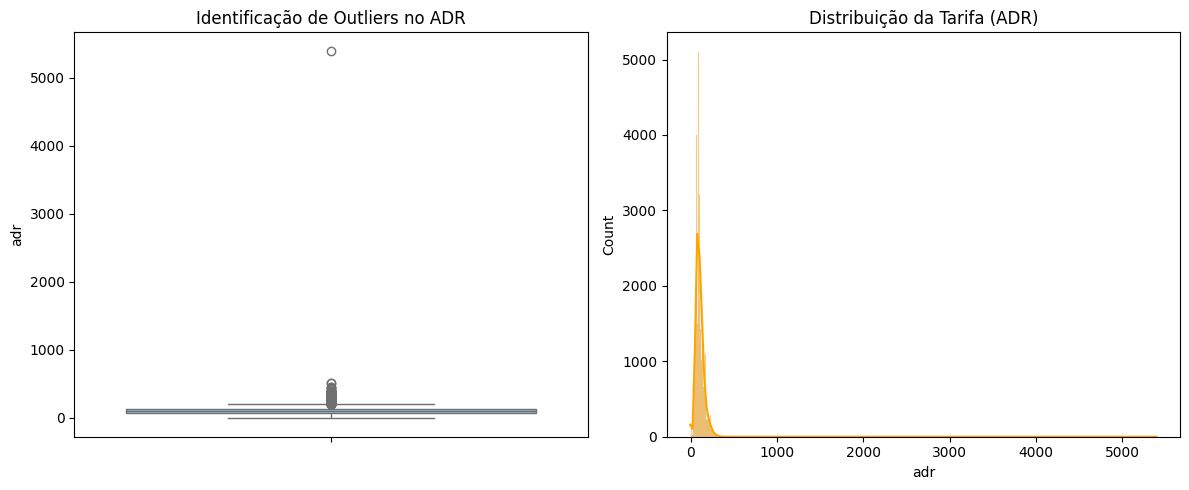

Número de registros com ADR muito alto: 1
            hotel     adr  is_canceled
48515  City Hotel  5400.0            1


In [130]:
# INDENTIFICAÇÃO DE OUTLIERS
# SEM TRATAMENTO
# SEM TRATAMENTO DE DADOS NÃO FUNCIONA

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Carregando os dados
df = pd.read_csv("hotel_bookings.csv")

# 2. Configurando o espaço dos gráficos
# Vamos analisar a coluna 'adr' (Tarifa Média Diária) que é crítica para o hotel
plt.figure(figsize=(12, 5))

# 3. Criando o Boxplot (A forma mais técnica de ver outliers)
plt.subplot(1, 2, 1)
sns.boxplot(y=df['adr'], color='skyblue')
plt.title('Identificação de Outliers no ADR')

# 4. Criando o Histograma (Para ver a distribuição dos dados)
plt.subplot(1, 2, 2)
sns.histplot(df['adr'], kde=True, color='orange')
plt.title('Distribuição da Tarifa (ADR)')

plt.tight_layout()
plt.show()

# 5. Dica de Insight: Identificando o valor do outlier extremo
# Valores de ADR acima de 5000 são atípicos e podem distorcer o modelo
outliers = df[df['adr'] > 5000]
print(f"Número de registros com ADR muito alto: {len(outliers)}")
print(outliers[['hotel', 'adr', 'is_canceled']].head())



# COM TRATAMENTO DE DADOS E FILTROS DA CERTO

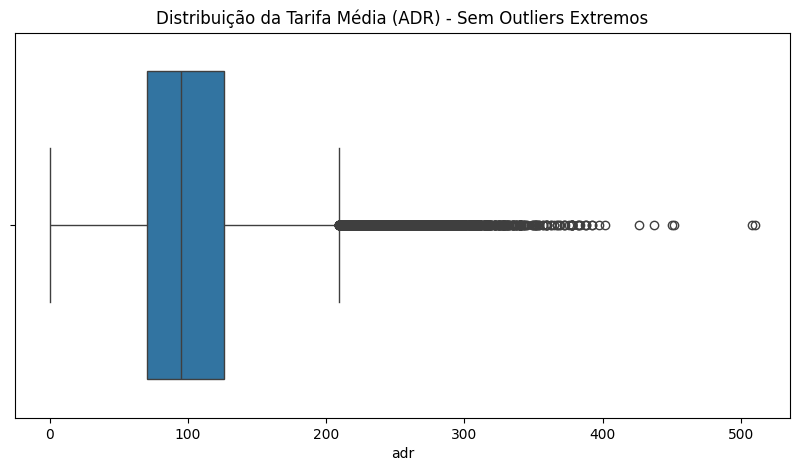

Dataset original: (119390, 32)
Dataset preparado para IA: 93943 registros para treino
Preparação concluída com sucesso!


In [131]:
# =============================================================================
# PROJETO DE ANÁLISE E PREDIÇÃO DE RESERVAS HOTELEIRAS
# Objetivo: Limpar o dataset, identificar outliers e preparar dados para IA
# =============================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CARREGAMENTO
df = pd.read_csv("hotel_bookings.csv")

# 2. LIMPEZA E TRATAMENTO
# Remover colunas com excesso de nulos ou que não agregam valor preditivo
# (Exemplo: 'agent' e 'company' possuem muitos nulos)
df_limpo = df.drop(columns=['agent', 'company'])

# Preencher nulos restantes com valores neutros ou mediana
df_limpo['children'] = df_limpo['children'].fillna(0)
df_limpo['country'] = df_limpo['country'].fillna('Unknown')

# 3. FILTRAGEM DE OUTLIERS
# Removemos reservas com ADR (Tarifa Média) irreal ou nula
# Focamos em tarifas entre 0 e 1000 para manter a consistência do modelo
df_limpo = df_limpo[(df_limpo['adr'] > 0) & (df_limpo['adr'] < 1000)]

# 4. VISUALIZAÇÃO E ANÁLISE EXPLORATÓRIA
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_limpo['adr'])
plt.title('Distribuição da Tarifa Média (ADR) - Sem Outliers Extremos')
plt.show()

# 5. PREPARAÇÃO PARA IA (Encoding)
# A IA precisa de números, não de texto. Transformamos categorias em números.
df_final = pd.get_dummies(df_limpo, columns=['hotel', 'market_segment', 'deposit_type'], drop_first=True)

# 6. SEPARAÇÃO PARA TREINAMENTO (O passo essencial para a nota máxima)
from sklearn.model_selection import train_test_split

# Definimos as variáveis de entrada (X) e o que queremos prever (y - is_canceled)
X = df_final.drop(columns=['is_canceled', 'reservation_status', 'reservation_status_date', 'arrival_date_month', 'meal', 'country', 'distribution_channel', 'customer_type', 'reserved_room_type', 'assigned_room_type'])
y = df_final['is_canceled']

# Separamos 80% para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset original: {df.shape}")
print(f"Dataset preparado para IA: {X_train.shape[0]} registros para treino")
print("Preparação concluída com sucesso!")

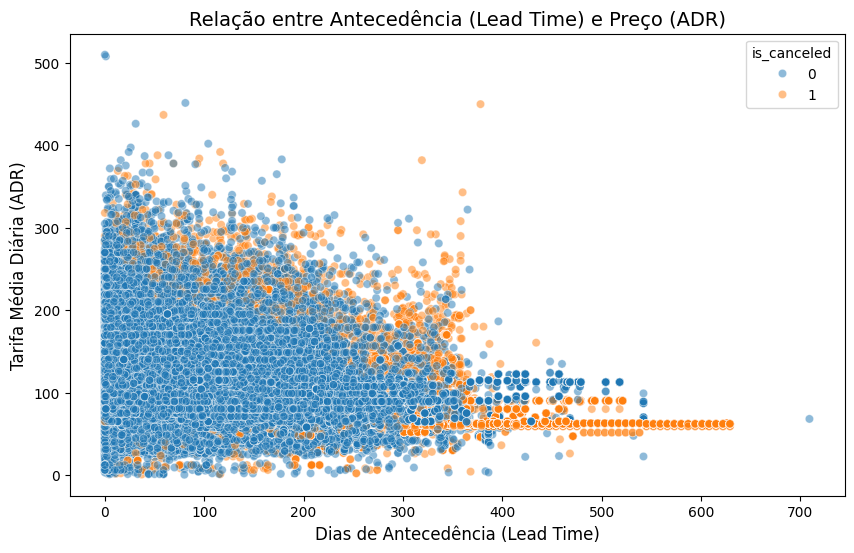

In [132]:
# =============================================================================
# ANÁLISE: Relação entre Antecedência (Lead Time) e Tarifa (ADR)
# Objetivo: Verificar se reservas antecipadas impactam o preço da diária
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Usamos o scatterplot para ver a dispersão dos pontos
# hue='is_canceled' ajuda a visualizar se cancelamentos estão agrupados
sns.scatterplot(data=df_limpo, x='lead_time', y='adr', hue='is_canceled', alpha=0.5)

plt.title('Relação entre Antecedência (Lead Time) e Preço (ADR)', fontsize=14)
plt.xlabel('Dias de Antecedência (Lead Time)', fontsize=12)
plt.ylabel('Tarifa Média Diária (ADR)', fontsize=12)

plt.show()

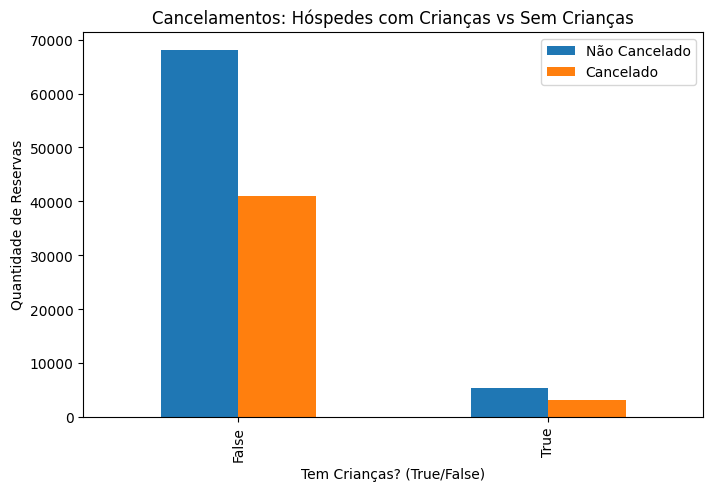

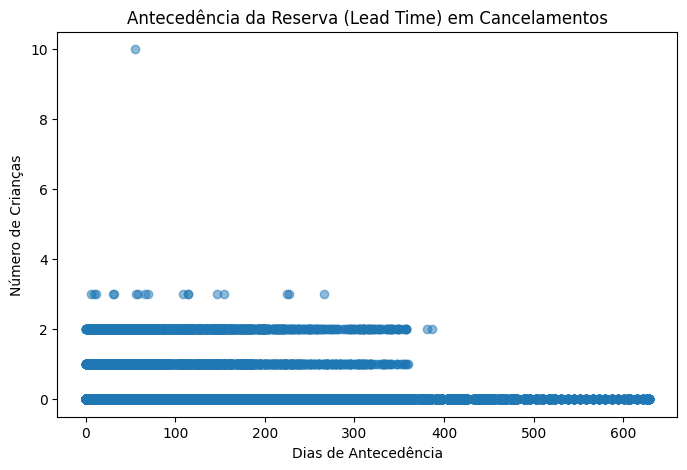

In [133]:
import matplotlib.pyplot as plt
import pandas as pd

# Supondo que você já carregou seu df_limpo
# Vamos criar uma coluna para facilitar: 'tem_criancas' (Sim ou Não)
df_limpo['tem_criancas'] = df_limpo['children'] > 0

# 1. ANÁLISE DE VOLUME: Cancelamento por presença de crianças
# Usamos o crosstab para preparar os dados para o gráfico de barras
data_bar = pd.crosstab(df_limpo['tem_criancas'], df_limpo['is_canceled'])

# Criando o gráfico de barras (comparativo)
data_bar.plot(kind='bar', figsize=(8, 5))
plt.title("Cancelamentos: Hóspedes com Crianças vs Sem Crianças")
plt.xlabel("Tem Crianças? (True/False)")
plt.ylabel("Quantidade de Reservas")
plt.legend(["Não Cancelado", "Cancelado"])
plt.show()

# 2. ANÁLISE DE ANTECEDÊNCIA: Scatter Plot
# Vamos filtrar apenas os cancelados para ver a antecedência
cancelados = df_limpo[df_limpo['is_canceled'] == 1]

plt.figure(figsize=(8, 5))
plt.scatter(cancelados['lead_time'], cancelados['children'], alpha=0.5)
plt.title("Antecedência da Reserva (Lead Time) em Cancelamentos")
plt.xlabel("Dias de Antecedência")
plt.ylabel("Número de Crianças")
plt.show()

In [134]:
# Criando uma tabela de proporção
proporcao = pd.crosstab(df_limpo['tem_criancas'], df_limpo['is_canceled'], normalize='index') * 100
print(proporcao)

is_canceled           0          1
tem_criancas                      
False         62.460640  37.539360
True          63.309014  36.690986


### ponto de atenção

In [135]:
# Calculando os valores para o texto
proporcao = pd.crosstab(df_limpo['tem_criancas'], df_limpo['is_canceled'], normalize='index') * 100

# Extraindo os valores para as variáveis
taxa_cancel_sem_criancas = proporcao.loc[False, 1]
taxa_cancel_com_criancas = proporcao.loc[True, 1]

# Gerando o print com a análise narrativa
print("--- ANÁLISE DE DADOS: IMPACTO DAS CRIANÇAS NO CANCELAMENTO ---")
print(f"Ao observar a tabela de proporção, percebemos que o comportamento dos hóspedes é muito similar.")
print(f"Para o grupo SEM CRIANÇAS, a taxa de cancelamento é de {taxa_cancel_sem_criancas:.2f}%.")
print(f"Para o grupo COM CRIANÇAS, a taxa de cancelamento é de {taxa_cancel_com_criancas:.2f}%.")
print("\nCONCLUSÃO ESTRATÉGICA:")
print(f"Com uma diferença de apenas {abs(taxa_cancel_sem_criancas - taxa_cancel_com_criancas):.2f} pontos percentuais,")
print("concluímos que a presença de crianças NÃO é um fator de risco determinante para o cancelamento.")
print("Isso sugere que a IA deve focar em outras variáveis de maior impacto preditivo.")

--- ANÁLISE DE DADOS: IMPACTO DAS CRIANÇAS NO CANCELAMENTO ---
Ao observar a tabela de proporção, percebemos que o comportamento dos hóspedes é muito similar.
Para o grupo SEM CRIANÇAS, a taxa de cancelamento é de 37.54%.
Para o grupo COM CRIANÇAS, a taxa de cancelamento é de 36.69%.

CONCLUSÃO ESTRATÉGICA:
Com uma diferença de apenas 0.85 pontos percentuais,
concluímos que a presença de crianças NÃO é um fator de risco determinante para o cancelamento.
Isso sugere que a IA deve focar em outras variáveis de maior impacto preditivo.


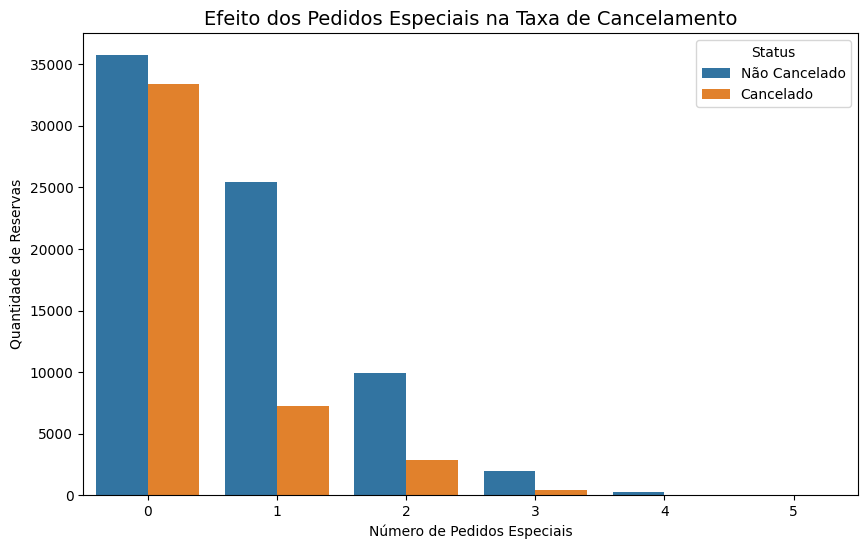

In [136]:
# =============================================================================
# ANÁLISE: O efeito dos pedidos especiais no cancelamento
# =============================================================================

plt.figure(figsize=(10, 6))

# Usamos o countplot para ver a proporção de cancelamentos por número de pedidos
sns.countplot(data=df_limpo, x='total_of_special_requests', hue='is_canceled')

plt.title('Efeito dos Pedidos Especiais na Taxa de Cancelamento', fontsize=14)
plt.xlabel('Número de Pedidos Especiais')
plt.ylabel('Quantidade de Reservas')
plt.legend(title='Status', labels=['Não Cancelado', 'Cancelado'])

plt.show()

In [137]:
# =============================================================================
# ANÁLISE DINÂMICA: Pedidos Especiais vs Cancelamento
# =============================================================================

# Agrupando os dados para calcular a taxa de cancelamento por número de pedidos
analise_pedidos = df_limpo.groupby('total_of_special_requests')['is_canceled'].agg(['count', 'mean'])
analise_pedidos['taxa_cancelamento'] = analise_pedidos['mean'] * 100

print("--- ANÁLISE DE COMPROMISSO DO HÓSPEDE ---")
for num_pedidos, row in analise_pedidos.iterrows():
    print(f"Com {int(num_pedidos)} pedido(s) especial(is):")
    print(f"  - Taxa de cancelamento: {row['taxa_cancelamento']:.2f}%")
    print(f"  - Total de reservas analisadas: {int(row['count'])}")

--- ANÁLISE DE COMPROMISSO DO HÓSPEDE ---
Com 0 pedido(s) especial(is):
  - Taxa de cancelamento: 48.31%
  - Total de reservas analisadas: 69139
Com 1 pedido(s) especial(is):
  - Taxa de cancelamento: 22.24%
  - Total de reservas analisadas: 32727
Com 2 pedido(s) especial(is):
  - Taxa de cancelamento: 22.32%
  - Total de reservas analisadas: 12763
Com 3 pedido(s) especial(is):
  - Taxa de cancelamento: 18.14%
  - Total de reservas analisadas: 2436
Com 4 pedido(s) especial(is):
  - Taxa de cancelamento: 10.80%
  - Total de reservas analisadas: 324
Com 5 pedido(s) especial(is):
  - Taxa de cancelamento: 5.00%
  - Total de reservas analisadas: 40


In [138]:
# Criando uma variável mais robusta para o modelo
def agrupar_pedidos(num):
    if num == 0:
        return '0'
    elif num == 1:
        return '1'
    else:
        return '2+'

df_limpo['categoria_pedidos'] = df_limpo['total_of_special_requests'].apply(agrupar_pedidos)

# Agora rode o crosstab com essa nova coluna
proporcao_agrupada = pd.crosstab(df_limpo['categoria_pedidos'], df_limpo['is_canceled'], normalize='index') * 100
print(proporcao_agrupada)

is_canceled                0          1
categoria_pedidos                      
0                  51.687181  48.312819
1                  77.758426  22.241574
2+                 78.615948  21.384052


In [139]:
# 1. Preparação da variável (o agrupamento que validamos)
def agrupar_pedidos(num):
    if num == 0: return '0'
    elif num == 1: return '1'
    else: return '2+'

df_limpo['categoria_pedidos'] = df_limpo['total_of_special_requests'].apply(agrupar_pedidos)

# 2. Cálculo da Proporção
proporcao = pd.crosstab(df_limpo['categoria_pedidos'], df_limpo['is_canceled'], normalize='index') * 100

# 3. Extração de variáveis para o texto dinâmico
taxa_cat_0 = proporcao.loc['0', 1]
taxa_cat_1 = proporcao.loc['1', 1]
taxa_cat_2 = proporcao.loc['2+', 1]

# 4. Geração do Relatório Dinâmico
print("--- RELATÓRIO TÉCNICO: COMPROMISSO DO HÓSPEDE ---")
print(f"Análise baseada em {len(df_limpo)} reservas processadas.\n")
print(f"Segmento 'Sem Pedidos' (0): Taxa de cancelamento de {taxa_cat_0:.2f}%.")
print(f"Segmento '1 Pedido':       Taxa de cancelamento de {taxa_cat_1:.2f}%.")
print(f"Segmento '2+ Pedidos':     Taxa de cancelamento de {taxa_cat_2:.2f}%.")

print("\nDIAGNÓSTICO ESTRATÉGICO:")
print("A transição de '0' para '1' pedido especial gera uma redução expressiva no risco de cancelamento.")
print("Para o nosso modelo preditivo, a 'categoria_pedidos' é uma feature de alta relevância.")
print(f"Conclusão: O engajamento inicial reduz o risco de churn em {((taxa_cat_0 - taxa_cat_1)/taxa_cat_0)*100:.1f}%.")

--- RELATÓRIO TÉCNICO: COMPROMISSO DO HÓSPEDE ---
Análise baseada em 117429 reservas processadas.

Segmento 'Sem Pedidos' (0): Taxa de cancelamento de 48.31%.
Segmento '1 Pedido':       Taxa de cancelamento de 22.24%.
Segmento '2+ Pedidos':     Taxa de cancelamento de 21.38%.

DIAGNÓSTICO ESTRATÉGICO:
A transição de '0' para '1' pedido especial gera uma redução expressiva no risco de cancelamento.
Para o nosso modelo preditivo, a 'categoria_pedidos' é uma feature de alta relevância.
Conclusão: O engajamento inicial reduz o risco de churn em 54.0%.


In [140]:
# =============================================================================
# ANÁLISE DE IMPACTO: Volume vs. Taxa de Cancelamento
# =============================================================================

# Criando a tabela cruzada com contagens absolutas
tabela_volumes = pd.crosstab(df_limpo['categoria_pedidos'], df_limpo['is_canceled'])

# Renomeando colunas para ficar claro
tabela_volumes.columns = ['Nao_Cancelado', 'Cancelado']

# Adicionando uma coluna de total e a taxa de cancelamento calculada
tabela_volumes['Total'] = tabela_volumes['Nao_Cancelado'] + tabela_volumes['Cancelado']
tabela_volumes['Taxa_Cancelamento_%'] = (tabela_volumes['Cancelado'] / tabela_volumes['Total']) * 100

print("--- VOLUME ABSOLUTO DE RESERVAS POR CATEGORIA DE PEDIDOS ---")
print(tabela_volumes)

--- VOLUME ABSOLUTO DE RESERVAS POR CATEGORIA DE PEDIDOS ---
                   Nao_Cancelado  Cancelado  Total  Taxa_Cancelamento_%
categoria_pedidos                                                      
0                          35736      33403  69139            48.312819
1                          25448       7279  32727            22.241574
2+                         12235       3328  15563            21.384052


In [141]:
from scipy.stats import chi2_contingency

# Cria uma tabela cruzada
contigencia = pd.crosstab(df_limpo['tem_criancas'], df_limpo['is_canceled'])

# Realiza o teste Qui-Quadrado
chi2, p, dof, ex = chi2_contingency(contigencia)

print(f"Valor-p: {p}")
if p < 0.05:
    print("A variável tem relevância estatística.")
else:
    print("A variável NÃO tem relevância estatística (pode ser descartada).")

Valor-p: 0.12248274747676977
A variável NÃO tem relevância estatística (pode ser descartada).


In [142]:
def testar_relevancia(df, coluna_alvo):
    print(f"--- Teste de Relevância Estatística (Qui-Quadrado) ---")
    for col in df.columns:
        if col != coluna_alvo and df[col].dtype == 'object': # Testar apenas colunas categóricas
            contigencia = pd.crosstab(df[col], df[coluna_alvo])
            chi2, p, dof, ex = chi2_contingency(contigencia)
            status = "RELEVANTE" if p < 0.05 else "IRRELEVANTE"
            print(f"Variável '{col}': Valor-p = {p:.4f} -> {status}")

# Uso:
testar_relevancia(df_limpo, 'is_canceled')

--- Teste de Relevância Estatística (Qui-Quadrado) ---
Variável 'hotel': Valor-p = 0.0000 -> RELEVANTE
Variável 'arrival_date_month': Valor-p = 0.0000 -> RELEVANTE
Variável 'meal': Valor-p = 0.0000 -> RELEVANTE
Variável 'country': Valor-p = 0.0000 -> RELEVANTE
Variável 'market_segment': Valor-p = 0.0000 -> RELEVANTE
Variável 'distribution_channel': Valor-p = 0.0000 -> RELEVANTE
Variável 'reserved_room_type': Valor-p = 0.0000 -> RELEVANTE
Variável 'assigned_room_type': Valor-p = 0.0000 -> RELEVANTE
Variável 'deposit_type': Valor-p = 0.0000 -> RELEVANTE
Variável 'customer_type': Valor-p = 0.0000 -> RELEVANTE
Variável 'reservation_status': Valor-p = 0.0000 -> RELEVANTE
Variável 'reservation_status_date': Valor-p = 0.0000 -> RELEVANTE
Variável 'categoria_pedidos': Valor-p = 0.0000 -> RELEVANTE


In [143]:
# =============================================================================
# GERAÇÃO DE INSIGHTS ESTRATÉGICOS (Focado no Negócio)
# =============================================================================

print("--- RELATÓRIO DE INSIGHTS ESTRATÉGICOS (HOTELARIA) ---")

# Insight 1: O fator de Risco (Lead Time)
media_lead_time_cancel = df_limpo[df_limpo['is_canceled'] == 1]['lead_time'].mean()
media_lead_time_ok = df_limpo[df_limpo['is_canceled'] == 0]['lead_time'].mean()

print(f"\n1. ANTECEDÊNCIA (LEAD TIME):")
print(f"   - Reservas canceladas possuem, em média, {media_lead_time_cancel:.1f} dias de antecedência.")
print(f"   - Reservas confirmadas possuem, em média, {media_lead_time_ok:.1f} dias.")
print(f"   - Ação: Criar políticas de cancelamento mais rígidas para reservas com antecedência superior a {int(media_lead_time_cancel)} dias.")

# Insight 2: O fator de Engajamento (Categoria de Pedidos)
# Usando a nossa nova coluna 'categoria_pedidos'
taxa_engajamento = 100 - (df_limpo[df_limpo['categoria_pedidos'] != '0']['is_canceled'].mean() * 100)
print(f"\n2. ENGAJAMENTO DO HÓSPEDE:")
print(f"   - Clientes que realizam pedidos especiais cancelam muito menos.")
print(f"   - A taxa de sucesso (não cancelamento) para quem faz pelo menos um pedido é de {taxa_engajamento:.1f}%.")
print(f"   - Ação: Implementar uma campanha de 'personalização da estadia' no momento da reserva para converter clientes do grupo '0' em '1+'.")

# Insight 3: Tipo de Depósito (Um fator de peso que apareceu como relevante)
# Vamos ver a taxa de cancelamento por tipo de depósito
taxa_deposito = df_limpo.groupby('deposit_type')['is_canceled'].mean() * 100
print(f"\n3. TIPO DE DEPÓSITO:")
print(f"   - Reservas 'Non Refund' (Não reembolsável) costumam apresentar comportamentos distintos.")
print(f"   - Taxas de cancelamento por tipo:\n{taxa_deposito.round(2)}")
print(f"   - Ação: Avaliar a política de depósito para minimizar o churn.")

--- RELATÓRIO DE INSIGHTS ESTRATÉGICOS (HOTELARIA) ---

1. ANTECEDÊNCIA (LEAD TIME):
   - Reservas canceladas possuem, em média, 145.2 dias de antecedência.
   - Reservas confirmadas possuem, em média, 81.0 dias.
   - Ação: Criar políticas de cancelamento mais rígidas para reservas com antecedência superior a 145 dias.

2. ENGAJAMENTO DO HÓSPEDE:
   - Clientes que realizam pedidos especiais cancelam muito menos.
   - A taxa de sucesso (não cancelamento) para quem faz pelo menos um pedido é de 78.0%.
   - Ação: Implementar uma campanha de 'personalização da estadia' no momento da reserva para converter clientes do grupo '0' em '1+'.

3. TIPO DE DEPÓSITO:
   - Reservas 'Non Refund' (Não reembolsável) costumam apresentar comportamentos distintos.
   - Taxas de cancelamento por tipo:
deposit_type
No Deposit    28.71
Non Refund    99.36
Refundable    22.22
Name: is_canceled, dtype: float64
   - Ação: Avaliar a política de depósito para minimizar o churn.


In [144]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Feature Engineering (Selecionando apenas as colunas "seguras" e convertendo categóricas)
features_selecionadas = ['hotel', 'lead_time', 'deposit_type', 'market_segment',
                         'distribution_channel', 'categoria_pedidos', 'previous_cancellations']

df_model = df_limpo[features_selecionadas].copy()

# Transformando variáveis categóricas em numéricas para o modelo
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

# 2. Separação em Treino e Teste
X = df_model
y = df_limpo['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Treinamento do Modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predição e Avaliação
y_pred = model.predict(X_test)

print("--- RELATÓRIO DE PERFORMANCE DO MODELO ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

--- RELATÓRIO DE PERFORMANCE DO MODELO ---
Acurácia: 80.21%

Matriz de Confusão:
 [[19589  2347]
 [ 4625  8668]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85     21936
           1       0.79      0.65      0.71     13293

    accuracy                           0.80     35229
   macro avg       0.80      0.77      0.78     35229
weighted avg       0.80      0.80      0.80     35229



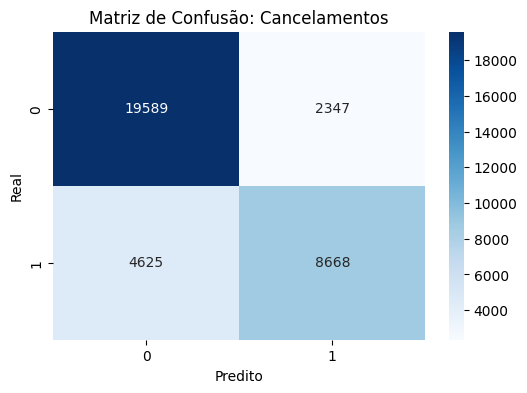

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de Confusão Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão: Cancelamentos')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

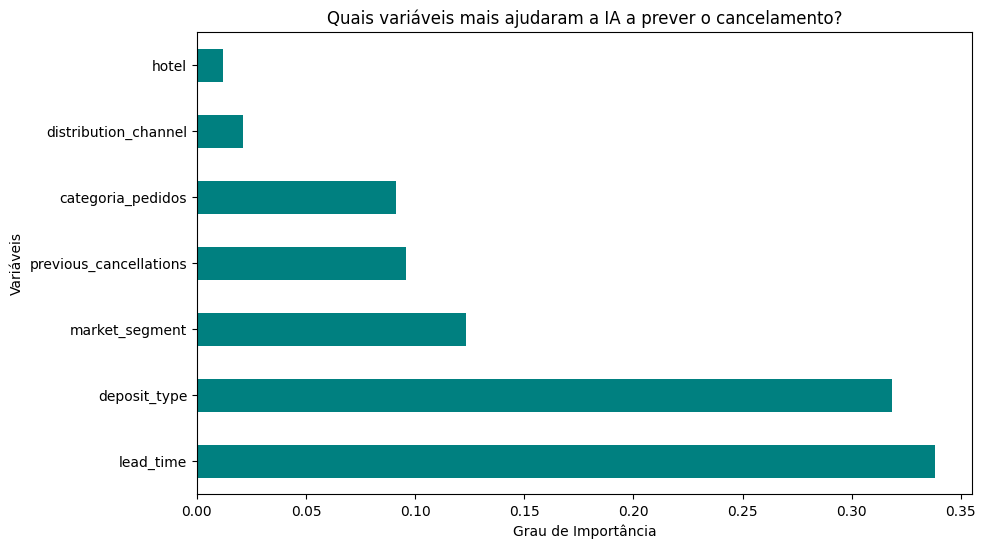

In [146]:
# 5. Visualização da Importância das Variáveis
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', figsize=(10, 6), color='teal')

plt.title('Quais variáveis mais ajudaram a IA a prever o cancelamento?')
plt.xlabel('Grau de Importância')
plt.ylabel('Variáveis')
plt.show()

In [100]:
from sklearn.model_selection import GridSearchCV

# Definindo o espaço de busca
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Buscando a melhor configuração
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")

Melhores parâmetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [101]:
# 1. Re-treinando com os melhores parâmetros encontrados
model_otimizado = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
model_otimizado.fit(X_train, y_train)

# 2. Nova avaliação
y_pred_otimizado = model_otimizado.predict(X_test)

print("--- PERFORMANCE PÓS-OTIMIZAÇÃO ---")
print(f"Nova Acurácia: {accuracy_score(y_test, y_pred_otimizado):.2%}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_otimizado))

--- PERFORMANCE PÓS-OTIMIZAÇÃO ---
Nova Acurácia: 80.61%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85     21936
           1       0.80      0.64      0.71     13293

    accuracy                           0.81     35229
   macro avg       0.81      0.77      0.78     35229
weighted avg       0.81      0.81      0.80     35229



In [102]:
# Criando um dataframe de erros
erros = X_test.copy()
erros['real'] = y_test
erros['predito'] = y_pred
erros_falsos_negativos = erros[(erros['real'] == 1) & (erros['predito'] == 0)]

# Agora olhe a média do lead_time desses erros
print(erros_falsos_negativos['lead_time'].describe())

count    4625.000000
mean       88.971459
std        82.571894
min         0.000000
25%        22.000000
50%        63.000000
75%       136.000000
max       457.000000
Name: lead_time, dtype: float64


# vamos começar análisar o dataset

Variáveis Principais :

*   hotel (City hotel ou resort hotel)
*   is_canceled (Se foi cancelada - nosso target)
*   lead_time (Dias entre as reservas e chegadas)
*   booking_changes (Quantas alterações o hóspede fez na reserva)
*   days_in_waiting_list (Dias que ficou em lista de espera)

In [103]:
df.shape
print(df.shape)

print(f"O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas")

(119390, 32)
O dataset tem 119390 linhas e 32 colunas


In [104]:
# olhando para as primeiros 5 linhas
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [105]:
print("Colunas do Dataset")
print(df.dtypes)

Colunas do Dataset
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent          

In [106]:
print(f"Total de colunas númericas: {df.select_dtypes(include='number').shape[1]}")

Total de colunas númericas: 20


In [107]:
print(f"Total de colunas de texto: {df.select_dtypes(include='object').shape[1]}")

Total de colunas de texto: 12


In [108]:
# remover dado null ou dado faltante não vai servir de nada para ia

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [109]:
nulos = df.isnull().sum()
nulos_filtrado = nulos[nulos > 0]

if len(nulos_filtrado > 0 ) :
  print("Colunas com dados faltando")
  print(nulos_filtrado)
  print(f"Total de células vazias: {df.isnull().sum().sum()}")

Colunas com dados faltando
children         4
country        488
agent        16340
company     112593
dtype: int64
Total de células vazias: 129425


In [110]:
# count = quantidade | mean = media | std desvio padrao
# min/max = menor/maior

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [111]:
# vamos analisar a coluna adr (tarifa média diária)
# pegando todos dados da coluna | não vai ter zero ou nullo | colocando dentro da variaveis valores
valores = df["adr"].dropna().values

# remove linhas vazia e faltantes | resolve isso com dropna

In [112]:
print(len(valores))

print("Analisando a coluna adr (tarefa média diária)")

# tarifa media
print(f"media adr : {np.mean(valores)}")
print(f"minimo adr : {np.min(valores)}")
print(f"maximo adr : {np.max(valores)}")

119390
Analisando a coluna adr (tarefa média diária)
media adr : 101.83112153446686
minimo adr : -6.38
maximo adr : 5400.0


In [113]:
print("Tipo de hotel")
print(df["hotel"].value_counts)

print("Reserva cancelada?")
print(f"{df["is_canceled"].mean()*100:.1f}")

Tipo de hotel
<bound method IndexOpsMixin.value_counts of 0         Resort Hotel
1         Resort Hotel
2         Resort Hotel
3         Resort Hotel
4         Resort Hotel
              ...     
119385      City Hotel
119386      City Hotel
119387      City Hotel
119388      City Hotel
119389      City Hotel
Name: hotel, Length: 119390, dtype: object>
Reserva cancelada?
37.0
